In [1]:
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
os.makedirs('../reports', exist_ok=True)

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [2]:
# -------------------------------------------------------
# Load test data and all saved models
# -------------------------------------------------------

X_test  = np.load('../data/processed/X_test.npy')
y_test  = np.load('../data/processed/y_test.npy')
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')

print(f"Test set  : X={X_test.shape}, y={y_test.shape}")
print(f"Train set : X={X_train.shape}, y={y_train.shape}")

# Load all saved model files from models/ folder
model_files = {
    'Logistic Regression' : '../models/logistic_regression.pkl',
    'Decision Tree'       : '../models/decision_tree.pkl',
    'Random Forest'       : '../models/random_forest.pkl',
    'XGBoost'             : '../models/xgboost.pkl',
    'SVM'                 : '../models/svm.pkl',
    'KNN'                 : '../models/knn.pkl',
    'Random Forest Tuned' : '../models/random_forest_tuned.pkl',
    'XGBoost Tuned'       : '../models/xgboost_tuned.pkl',
}

trained_models = {}
for name, path in model_files.items():
    if os.path.exists(path):
        trained_models[name] = joblib.load(path)
        print(f"  ✅ Loaded: {name}")
    else:
        print(f"  ⚠️  Not found (skipping): {name}")

print(f"\nTotal models loaded: {len(trained_models)}")

Test set  : X=(154, 12), y=(154,)
Train set : X=(800, 12), y=(800,)
  ✅ Loaded: Logistic Regression
  ✅ Loaded: Decision Tree
  ✅ Loaded: Random Forest
  ✅ Loaded: XGBoost
  ✅ Loaded: SVM
  ✅ Loaded: KNN
  ✅ Loaded: Random Forest Tuned
  ✅ Loaded: XGBoost Tuned

Total models loaded: 8


In [3]:
# -------------------------------------------------------
# 🧠 LEARN: What do evaluation metrics mean?
# -------------------------------------------------------
# Let's say our model checks 100 patients for diabetes:
#
# CONFUSION MATRIX — 4 possible outcomes:
# ┌─────────────────────────────────────────────────────┐
# │              │ Predicted NO  │ Predicted YES         │
# │──────────────│───────────────│──────────────────     │
# │ Actual NO    │ TN (correct!) │ FP (False Alarm)      │
# │ Actual YES   │ FN (Missed!)  │ TP (correct!)         │
# └─────────────────────────────────────────────────────┘
#
# ACCURACY  = (TP + TN) / Total        → Overall correct predictions
#             ⚠️ Misleading if data is imbalanced!
#
# PRECISION = TP / (TP + FP)           → Of all "Diabetic" predictions,
#             how many were actually diabetic?
#             High precision = fewer false alarms
#
# RECALL    = TP / (TP + FN)           → Of all actual diabetics,
#             how many did we catch?
#             High recall = fewer missed cases
#             ⭐ MOST IMPORTANT for medical diagnosis!
#             Missing a diabetic patient is dangerous!
#
# F1-SCORE  = 2 × (Precision × Recall) / (Precision + Recall)
#             Harmonic mean — balances both precision and recall
#
# ROC-AUC   = Area under the ROC curve
#             Measures how well model separates two classes
#             1.0 = perfect | 0.5 = random guessing

print("📚 Metrics explanation printed above as comments.")
print("   Read through the comments carefully!")
print("\n🎯 Priority for medical diagnosis:")
print("   1st → Recall    (don't miss diabetic patients!)")
print("   2nd → F1-Score  (balance precision & recall)")
print("   3rd → ROC-AUC   (overall class separation)")
print("   4th → Accuracy  (least reliable alone)")

📚 Metrics explanation printed above as comments.
   Read through the comments carefully!

🎯 Priority for medical diagnosis:
   1st → Recall    (don't miss diabetic patients!)
   2nd → F1-Score  (balance precision & recall)
   3rd → ROC-AUC   (overall class separation)
   4th → Accuracy  (least reliable alone)


In [4]:
# -------------------------------------------------------
# Evaluate every model on the test set
# -------------------------------------------------------

evaluation_results = {}

print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print("-" * 72)

for name, model in trained_models.items():
    # Get predictions
    y_pred      = model.predict(X_test)

    # Get probability scores for ROC-AUC
    # Some models use predict_proba, SVM with probability=True also supports it
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1
    else:
        y_prob = model.decision_function(X_test)

    # Calculate all metrics
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_prob)

    evaluation_results[name] = {
        'Accuracy'  : acc,
        'Precision' : precision,
        'Recall'    : recall,
        'F1-Score'  : f1,
        'ROC-AUC'   : roc_auc,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob
    }

    print(f"{name:<22} {acc*100:>8.2f}%  {precision*100:>8.2f}%  "
          f"{recall*100:>7.2f}%  {f1*100:>7.2f}%  {roc_auc*100:>8.2f}%")

print("\n✅ Evaluation complete for all models!")

Model                   Accuracy  Precision   Recall       F1   ROC-AUC
------------------------------------------------------------------------
Logistic Regression       77.27%     63.38%    83.33%    72.00%     84.33%
Decision Tree             88.31%     80.00%    88.89%    84.21%     92.66%
Random Forest             87.66%     79.66%    87.04%    83.19%     94.35%
XGBoost                   87.01%     80.36%    83.33%    81.82%     94.70%
SVM                       83.77%     73.77%    83.33%    78.26%     91.02%
KNN                       77.27%     64.18%    79.63%    71.07%     85.45%
Random Forest Tuned       87.66%     79.66%    87.04%    83.19%     94.35%
XGBoost Tuned             87.01%     79.31%    85.19%    82.14%     94.48%

✅ Evaluation complete for all models!


In [5]:
# -------------------------------------------------------
# Build a clean comparison DataFrame
# -------------------------------------------------------

summary_df = pd.DataFrame({
    name: {
        'Accuracy'  : f"{v['Accuracy']*100:.2f}%",
        'Precision' : f"{v['Precision']*100:.2f}%",
        'Recall'    : f"{v['Recall']*100:.2f}%",
        'F1-Score'  : f"{v['F1-Score']*100:.2f}%",
        'ROC-AUC'   : f"{v['ROC-AUC']*100:.2f}%"
    }
    for name, v in evaluation_results.items()
}).T   # Transpose so models are rows

# Rank models by F1-Score (best for medical classification)
numeric_df = pd.DataFrame({
    name: {
        'Accuracy'  : v['Accuracy'],
        'Precision' : v['Precision'],
        'Recall'    : v['Recall'],
        'F1-Score'  : v['F1-Score'],
        'ROC-AUC'   : v['ROC-AUC']
    }
    for name, v in evaluation_results.items()
}).T

numeric_df = numeric_df.sort_values('F1-Score', ascending=False)

print("📊 Model Comparison Table (sorted by F1-Score):\n")
print(numeric_df.mul(100).round(2).to_string())

# Save to CSV for report
numeric_df.mul(100).round(2).to_csv('../reports/model_comparison.csv')
print("\n✅ Saved to reports/model_comparison.csv")

📊 Model Comparison Table (sorted by F1-Score):

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Decision Tree           88.31      80.00   88.89     84.21    92.66
Random Forest           87.66      79.66   87.04     83.19    94.35
Random Forest Tuned     87.66      79.66   87.04     83.19    94.35
XGBoost Tuned           87.01      79.31   85.19     82.14    94.48
XGBoost                 87.01      80.36   83.33     81.82    94.70
SVM                     83.77      73.77   83.33     78.26    91.02
Logistic Regression     77.27      63.38   83.33     72.00    84.33
KNN                     77.27      64.18   79.63     71.07    85.45

✅ Saved to reports/model_comparison.csv


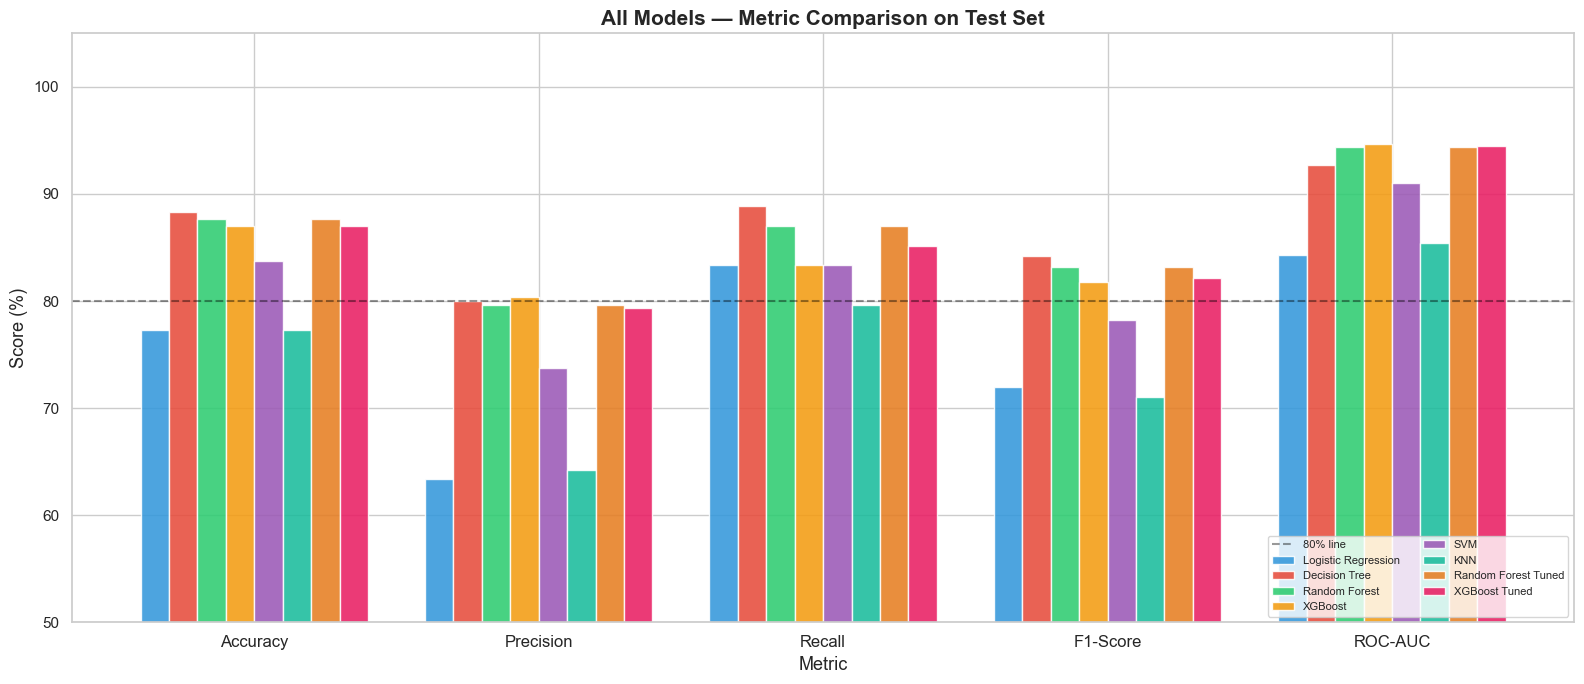

✅ Plot saved to reports/10_metrics_comparison.png


In [6]:
# -------------------------------------------------------
# PLOT: Side-by-side bar chart for all metrics
# -------------------------------------------------------

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = list(evaluation_results.keys())

# Build arrays for plotting
data_matrix = np.array([
    [evaluation_results[m][metric] * 100 for metric in metrics]
    for m in model_names
])

x     = np.arange(len(metrics))
width = 0.10
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#e91e63']

fig, ax = plt.subplots(figsize=(16, 7))

for i, (name, row) in enumerate(zip(model_names, data_matrix)):
    bars = ax.bar(x + i * width, row, width,
                  label=name, color=colors[i % len(colors)],
                  edgecolor='white', alpha=0.88)

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('All Models — Metric Comparison on Test Set',
             fontsize=15, fontweight='bold')
ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(50, 105)
ax.axhline(y=80, color='black', linestyle='--', alpha=0.4, label='80% line')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../reports/10_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to reports/10_metrics_comparison.png")

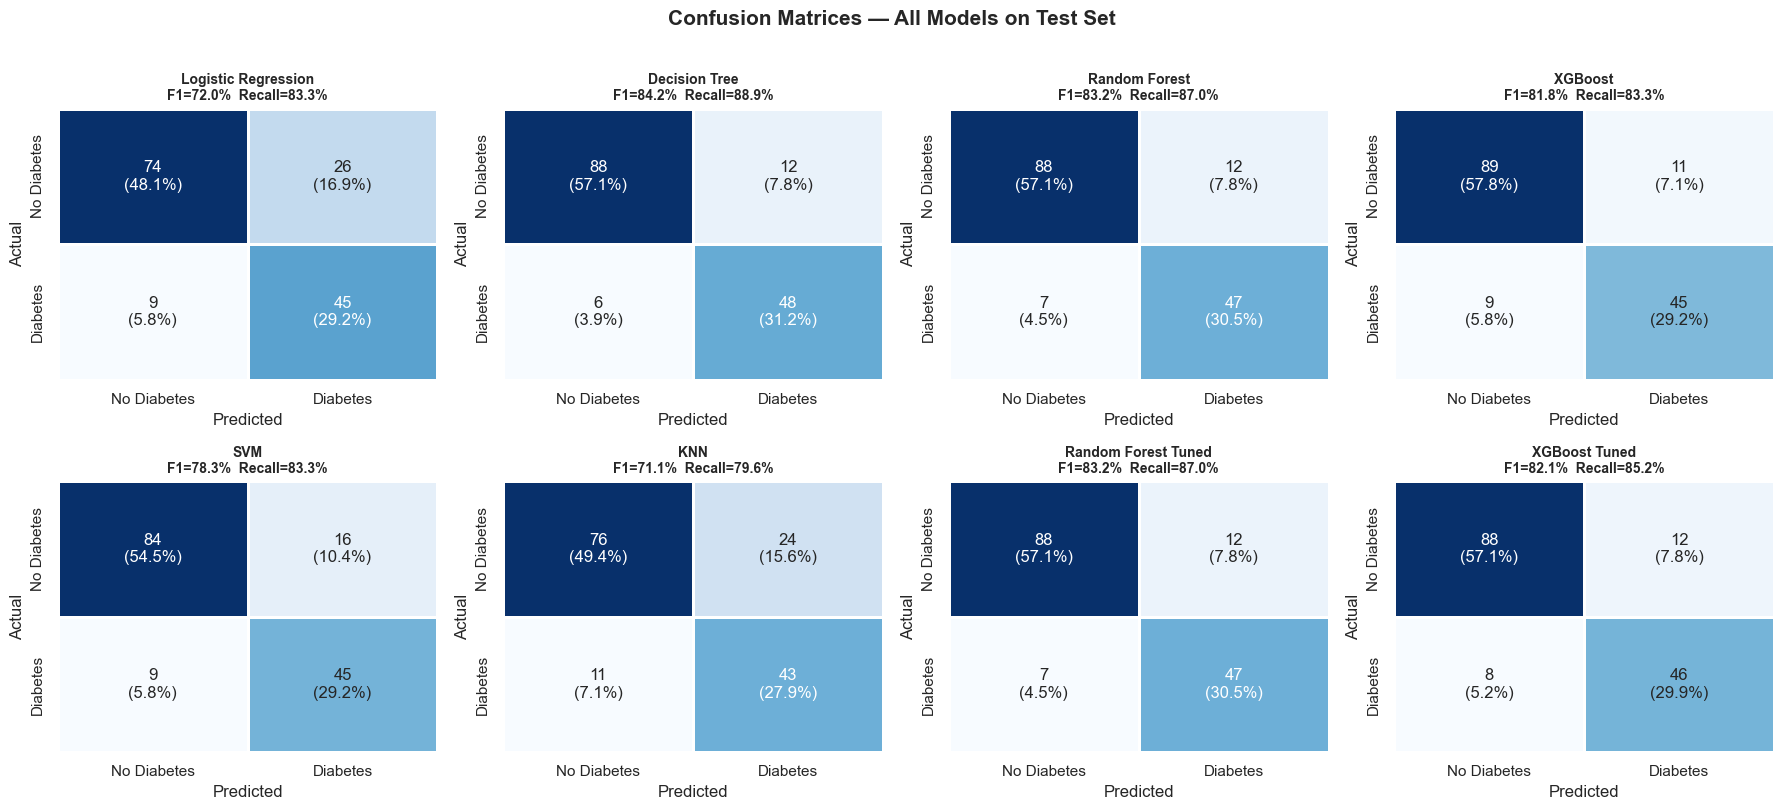

✅ Plot saved to reports/11_confusion_matrices.png


In [7]:
# -------------------------------------------------------
# PLOT: Confusion Matrix for every model
# -------------------------------------------------------
# A confusion matrix shows exactly WHERE the model
# makes mistakes — which is crucial for medical diagnosis.

n_models = len(trained_models)
ncols    = 4
nrows    = (n_models + ncols - 1) // ncols   # ceiling division

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 4.5, nrows * 4))
axes = axes.flatten()

for i, (name, values) in enumerate(evaluation_results.items()):
    cm = confusion_matrix(y_test, values['y_pred'])

    # Annotate with counts AND percentages
    total  = cm.sum()
    labels = np.array([
        [f"{cm[0,0]}\n({cm[0,0]/total*100:.1f}%)", f"{cm[0,1]}\n({cm[0,1]/total*100:.1f}%)"],
        [f"{cm[1,0]}\n({cm[1,0]/total*100:.1f}%)", f"{cm[1,1]}\n({cm[1,1]/total*100:.1f}%)"]
    ])

    sns.heatmap(
        cm,
        annot=labels,
        fmt='',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['No Diabetes', 'Diabetes'],
        yticklabels=['No Diabetes', 'Diabetes'],
        linewidths=1,
        cbar=False
    )

    f1  = values['F1-Score'] * 100
    rec = values['Recall']   * 100
    axes[i].set_title(f'{name}\nF1={f1:.1f}%  Recall={rec:.1f}%',
                       fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models on Test Set',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/11_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to reports/11_confusion_matrices.png")

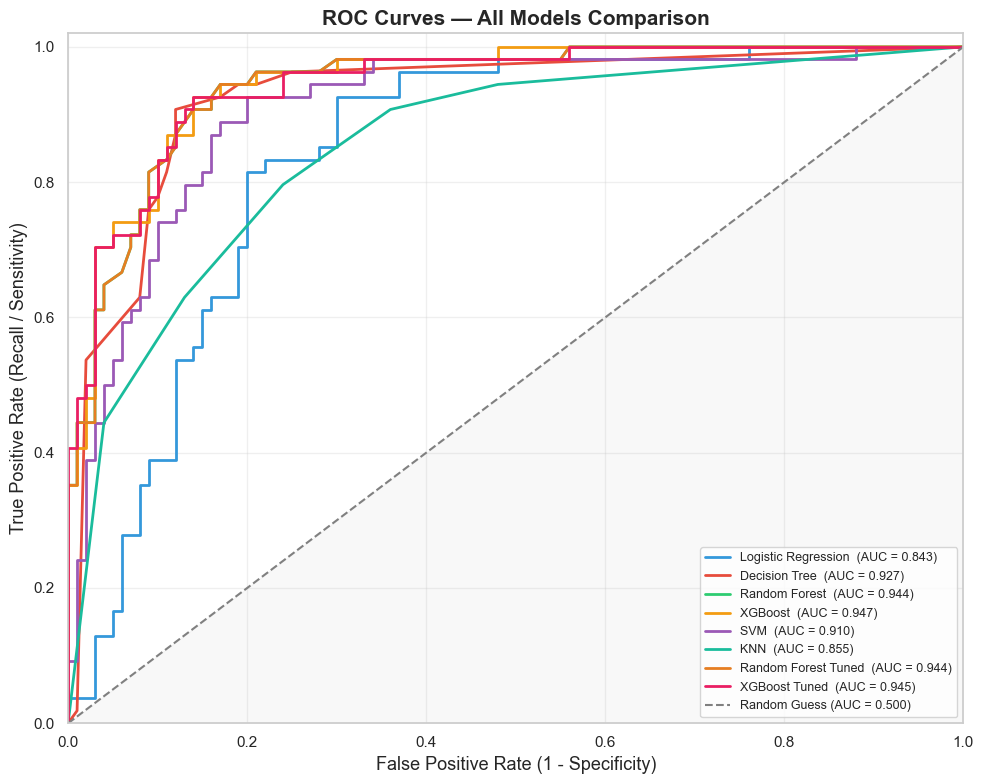

✅ Plot saved to reports/12_roc_curves.png


In [8]:
# -------------------------------------------------------
# PLOT: ROC Curves — all models on one graph
# -------------------------------------------------------
# ROC Curve plots:
#   X-axis = False Positive Rate (FPR) — wrongly flagging healthy patients
#   Y-axis = True Positive Rate (TPR) = Recall — catching real diabetics
#
# The curve shows the trade-off between sensitivity and specificity
# at different decision thresholds.
#
# AUC (Area Under Curve):
#   1.0 = perfect classifier
#   0.5 = random guessing (diagonal line)
#   Higher AUC = model separates classes better overall

fig, ax = plt.subplots(figsize=(10, 8))

colors_roc = ['#3498db','#e74c3c','#2ecc71','#f39c12',
               '#9b59b6','#1abc9c','#e67e22','#e91e63']

for (name, values), color in zip(evaluation_results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, values['y_prob'])
    auc_val      = values['ROC-AUC']

    ax.plot(fpr, tpr,
            label=f"{name}  (AUC = {auc_val:.3f})",
            color=color,
            linewidth=2)

# Random guessing baseline
ax.plot([0, 1], [0, 1],
        color='grey', linestyle='--',
        linewidth=1.5, label='Random Guess (AUC = 0.500)')

ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=13)
ax.set_title('ROC Curves — All Models Comparison', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/12_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to reports/12_roc_curves.png")

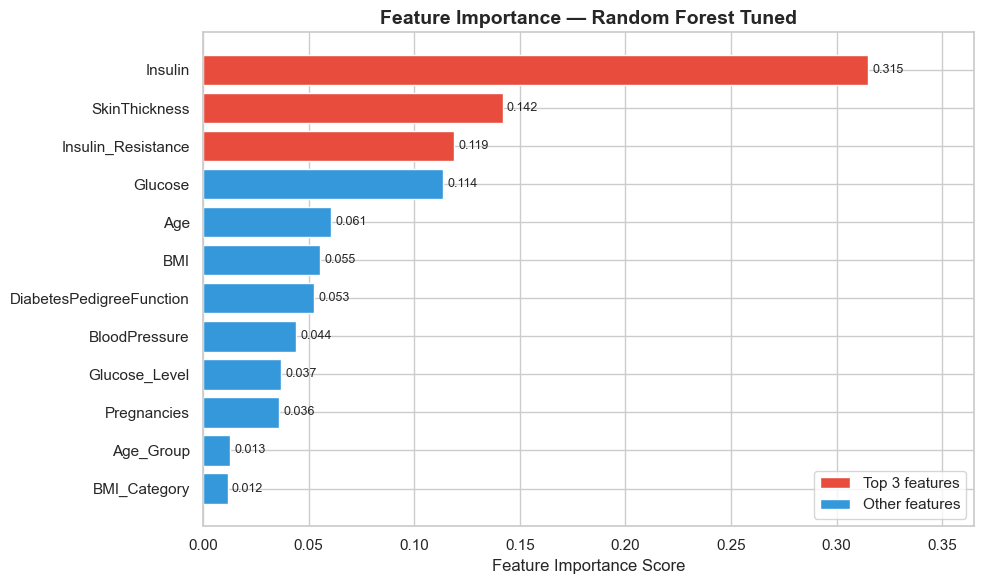

✅ Plot saved to reports/13_feature_importance.png

🏆 Top 3 most important features:
   1. Insulin (0.315)
   2. SkinThickness (0.142)
   3. Insulin_Resistance (0.119)


In [9]:
# -------------------------------------------------------
# PLOT: Feature Importance from best tree-based model
# -------------------------------------------------------
# Feature importance tells us which features the model
# relied on MOST to make predictions.
# High importance = that feature strongly influences outcome.

feature_names = joblib.load('../models/feature_names.pkl')

# Use tuned Random Forest or XGBoost (whichever is available & best)
best_tree_name = 'Random Forest Tuned' if 'Random Forest Tuned' in trained_models else 'Random Forest'
best_tree_model = trained_models[best_tree_name]

importances = best_tree_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

sorted_features     = [feature_names[i] for i in sorted_idx]
sorted_importances  = importances[sorted_idx]

# Color: top 3 features highlighted
bar_colors = ['#e74c3c' if i < 3 else '#3498db'
              for i in range(len(sorted_features))]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_features[::-1],
               sorted_importances[::-1],
               color=bar_colors[::-1],
               edgecolor='white')

# Add value labels
for bar, val in zip(bars, sorted_importances[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title(f'Feature Importance — {best_tree_name}',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, sorted_importances.max() + 0.05)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Top 3 features'),
                   Patch(facecolor='#3498db', label='Other features')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plot saved to reports/13_feature_importance.png")
print(f"\n🏆 Top 3 most important features:")
for i in range(3):
    print(f"   {i+1}. {sorted_features[i]} ({sorted_importances[i]:.3f})")

In [10]:
# -------------------------------------------------------
# Detailed Classification Report for the BEST model
# -------------------------------------------------------
# Find best model by F1-Score

best_model_name = max(evaluation_results,
                      key=lambda x: evaluation_results[x]['F1-Score'])
best_values     = evaluation_results[best_model_name]

print(f"🏆 Best Model: {best_model_name}")
print(f"   Accuracy  : {best_values['Accuracy']*100:.2f}%")
print(f"   Precision : {best_values['Precision']*100:.2f}%")
print(f"   Recall    : {best_values['Recall']*100:.2f}%")
print(f"   F1-Score  : {best_values['F1-Score']*100:.2f}%")
print(f"   ROC-AUC   : {best_values['ROC-AUC']*100:.2f}%")
print()
print("📋 Detailed Classification Report:")
print("-" * 50)
print(classification_report(
    y_test,
    best_values['y_pred'],
    target_names=['Non-Diabetic', 'Diabetic']
))

# Save best model separately with a clear name
best_model_obj = trained_models[best_model_name]
joblib.dump(best_model_obj, '../models/best_model.pkl')
joblib.dump(best_model_name, '../models/best_model_name.pkl')
print(f"✅ Best model saved as models/best_model.pkl")

🏆 Best Model: Decision Tree
   Accuracy  : 88.31%
   Precision : 80.00%
   Recall    : 88.89%
   F1-Score  : 84.21%
   ROC-AUC   : 92.66%

📋 Detailed Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

Non-Diabetic       0.94      0.88      0.91       100
    Diabetic       0.80      0.89      0.84        54

    accuracy                           0.88       154
   macro avg       0.87      0.88      0.87       154
weighted avg       0.89      0.88      0.88       154

✅ Best model saved as models/best_model.pkl


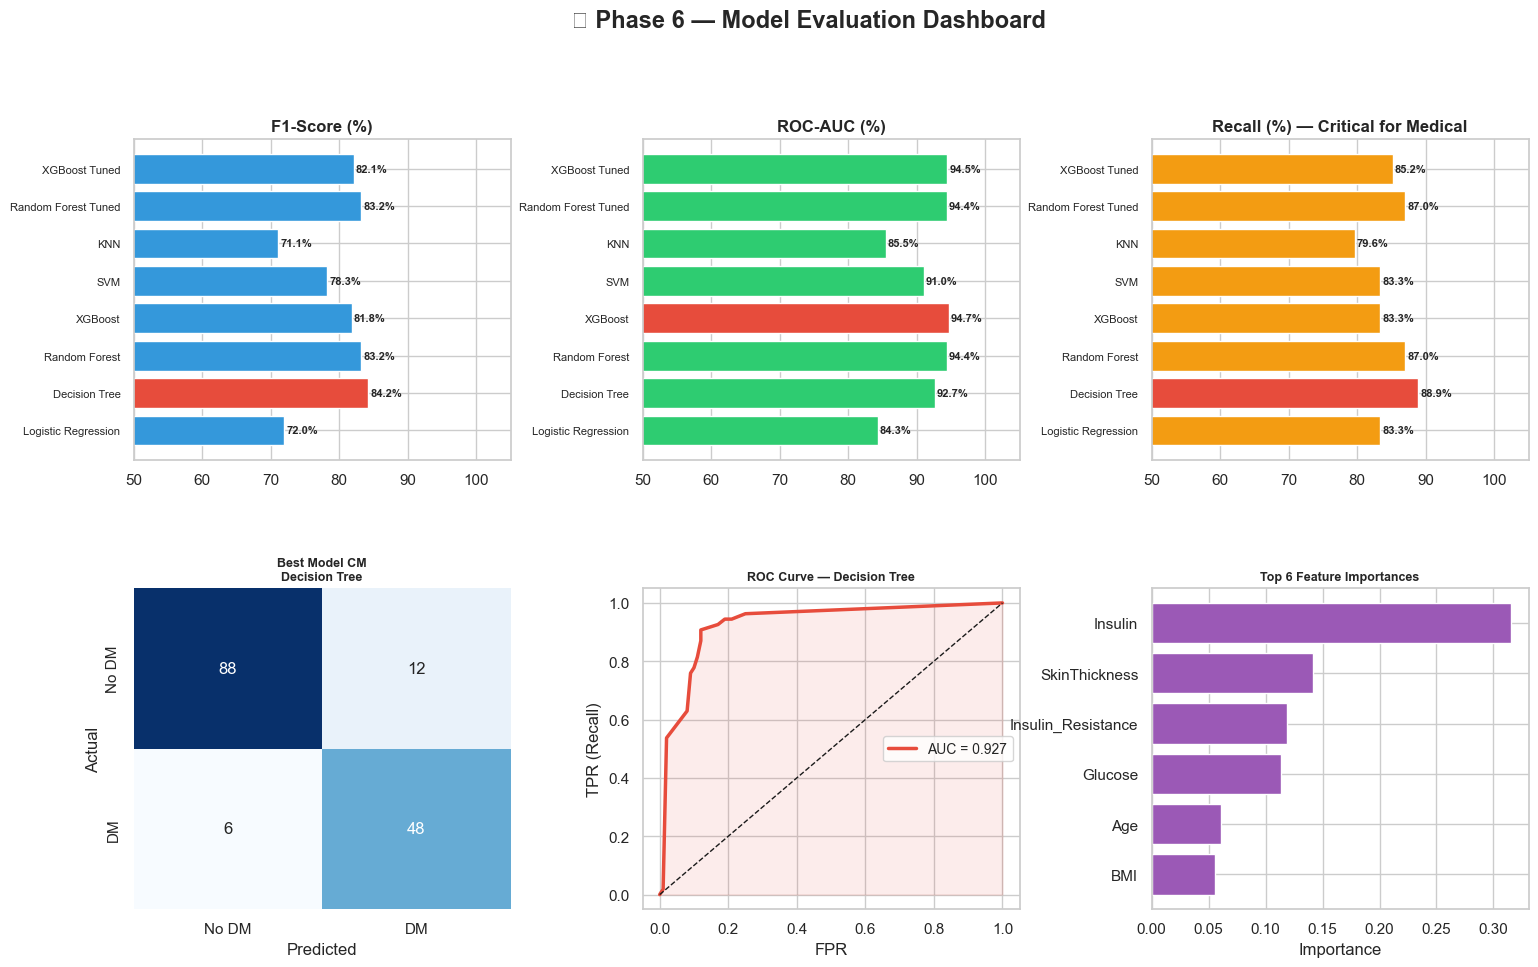

✅ Dashboard saved to reports/14_evaluation_dashboard.png


In [12]:
# -------------------------------------------------------
# PLOT: Final Summary Dashboard
# -------------------------------------------------------
# One clean figure summarising all key findings

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

model_list  = list(evaluation_results.keys())
f1_scores   = [evaluation_results[m]['F1-Score']*100  for m in model_list]
roc_scores  = [evaluation_results[m]['ROC-AUC']*100   for m in model_list]
recall_scores = [evaluation_results[m]['Recall']*100  for m in model_list]

bar_c = ['#e74c3c' if s == max(f1_scores) else '#3498db' for s in f1_scores]

# --- Panel 1: F1 Scores ---
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.barh(model_list, f1_scores, color=bar_c, edgecolor='white')
for bar, val in zip(bars, f1_scores):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')
ax1.set_title('F1-Score (%)', fontweight='bold')
ax1.set_xlim(50, 105)
ax1.tick_params(axis='y', labelsize=8)

# --- Panel 2: ROC-AUC ---
ax2 = fig.add_subplot(gs[0, 1])
roc_c = ['#e74c3c' if s == max(roc_scores) else '#2ecc71' for s in roc_scores]
bars2 = ax2.barh(model_list, roc_scores, color=roc_c, edgecolor='white')
for bar, val in zip(bars2, roc_scores):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')
ax2.set_title('ROC-AUC (%)', fontweight='bold')
ax2.set_xlim(50, 105)
ax2.tick_params(axis='y', labelsize=8)

# --- Panel 3: Recall ---
ax3 = fig.add_subplot(gs[0, 2])
rec_c = ['#e74c3c' if s == max(recall_scores) else '#f39c12' for s in recall_scores]
bars3 = ax3.barh(model_list, recall_scores, color=rec_c, edgecolor='white')
for bar, val in zip(bars3, recall_scores):
    ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')
ax3.set_title('Recall (%) — Critical for Medical', fontweight='bold')
ax3.set_xlim(50, 105)
ax3.tick_params(axis='y', labelsize=8)

# --- Panel 4: Best Model Confusion Matrix ---
ax4 = fig.add_subplot(gs[1, 0])
cm_best = confusion_matrix(y_test, best_values['y_pred'])
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['No DM', 'DM'],
            yticklabels=['No DM', 'DM'], cbar=False)
ax4.set_title(f'Best Model CM\n{best_model_name}', fontweight='bold', fontsize=9)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

# --- Panel 5: ROC Curve for Best Model Only ---
ax5 = fig.add_subplot(gs[1, 1])
fpr_b, tpr_b, _ = roc_curve(y_test, best_values['y_prob'])
ax5.plot(fpr_b, tpr_b, color='#e74c3c', linewidth=2.5,
         label=f"AUC = {best_values['ROC-AUC']:.3f}")
ax5.plot([0,1],[0,1], 'k--', linewidth=1)
ax5.fill_between(fpr_b, tpr_b, alpha=0.1, color='#e74c3c')
ax5.set_xlabel('FPR')
ax5.set_ylabel('TPR (Recall)')
ax5.set_title(f'ROC Curve — {best_model_name}', fontweight='bold', fontsize=9)
ax5.legend(fontsize=10)

# --- Panel 6: Feature Importance ---
ax6 = fig.add_subplot(gs[1, 2])
top_n = 6
top_idx  = sorted_idx[:top_n]
top_feat = [feature_names[i] for i in top_idx]
top_imp  = importances[top_idx]
ax6.barh(top_feat[::-1], top_imp[::-1],
         color='#9b59b6', edgecolor='white')
ax6.set_title('Top 6 Feature Importances', fontweight='bold', fontsize=9)
ax6.set_xlabel('Importance')

plt.suptitle('🏆 Phase 6 — Model Evaluation Dashboard',
             fontsize=17, fontweight='bold', y=1.01)
plt.savefig('../reports/14_evaluation_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved to reports/14_evaluation_dashboard.png")

In [13]:
print("=" * 60)
print("         PHASE 6 — EVALUATION SUMMARY")
print("=" * 60)
print()

# Print ranked table
print(f"{'Rank':<5} {'Model':<25} {'F1':>7} {'Recall':>8} {'ROC-AUC':>9}")
print("-" * 58)
ranked = sorted(evaluation_results.items(),
                key=lambda x: x[1]['F1-Score'], reverse=True)
for rank, (name, vals) in enumerate(ranked, 1):
    marker = "🥇" if rank == 1 else ("🥈" if rank == 2 else ("🥉" if rank == 3 else "  "))
    print(f"{marker:<5} {name:<25} "
          f"{vals['F1-Score']*100:>6.2f}%  "
          f"{vals['Recall']*100:>6.2f}%  "
          f"{vals['ROC-AUC']*100:>8.2f}%")

print()
print(f"🏆 Best Model Selected : {best_model_name}")
print(f"   Saved to           : models/best_model.pkl")
print()
print("📁 Reports generated:")
reports = [
    "10_metrics_comparison.png",
    "11_confusion_matrices.png",
    "12_roc_curves.png",
    "13_feature_importance.png",
    "14_evaluation_dashboard.png",
    "model_comparison.csv"
]
for r in reports:
    print(f"   ✅ reports/{r}")
print()
print("➡️  Ready for Phase 7: Overfitting & Underfitting Analysis!")
print("=" * 60)

         PHASE 6 — EVALUATION SUMMARY

Rank  Model                          F1   Recall   ROC-AUC
----------------------------------------------------------
🥇     Decision Tree              84.21%   88.89%     92.66%
🥈     Random Forest              83.19%   87.04%     94.35%
🥉     Random Forest Tuned        83.19%   87.04%     94.35%
      XGBoost Tuned              82.14%   85.19%     94.48%
      XGBoost                    81.82%   83.33%     94.70%
      SVM                        78.26%   83.33%     91.02%
      Logistic Regression        72.00%   83.33%     84.33%
      KNN                        71.07%   79.63%     85.45%

🏆 Best Model Selected : Decision Tree
   Saved to           : models/best_model.pkl

📁 Reports generated:
   ✅ reports/10_metrics_comparison.png
   ✅ reports/11_confusion_matrices.png
   ✅ reports/12_roc_curves.png
   ✅ reports/13_feature_importance.png
   ✅ reports/14_evaluation_dashboard.png
   ✅ reports/model_comparison.csv

➡️  Ready for Phase 7: Overfitti